<h1 style="text-align: center; font-family: Arial"> TP 1 - Séance 1 </h1>
<h2 style="text-align: center; font-family: Arial"> Qualité d'image </h2>

Équipe #0
- Nom, Prénom (Matricule)
- Nom, Prénom (Matricule)

In [3]:
# Importe les modules qui seront utilisés dans le laboratoire.
import numpy as np
from IPython.display import clear_output
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread

%matplotlib inline
# Étend la taille des figures
plt.rcParams["figure.figsize"] = (12, 7)

<span style='color: red;'> Attention : Lisez également le fichier Énoncé TP1.pdf que nous vous donnons. Il contient les questions du TP mais également des informations supplémentaires et astuces pour vous aider.  
</span>

**1.** Ouvrez et affichez l'image ```brain_tumor.jpg```. 

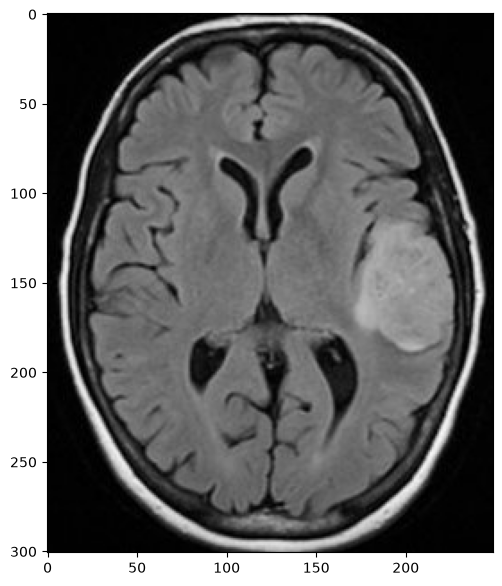

In [4]:
img = plt.imread('brain_tumor.jpg')

plt.imshow(img)
plt.show()


**2.** Déterminez graphiquement la largeur approximative de la tumeur en pixel (selon l'axe transversal).

Affichez cette largeur sous forme d'une ligne pointillée délimitée par deux points, avec la fonction ```ax.plot(x, y)```. 

# Exercice I: Étude de la résolution
## Mise en place des fonctions

<span style='color: red;'> Attention : tous les fichiers et les images dont vous aurez besoin pour cette séance sont dans le dossier 'fichiers_seance_1'. Vos chemins devront être ajustés en conséquence. 
</span>

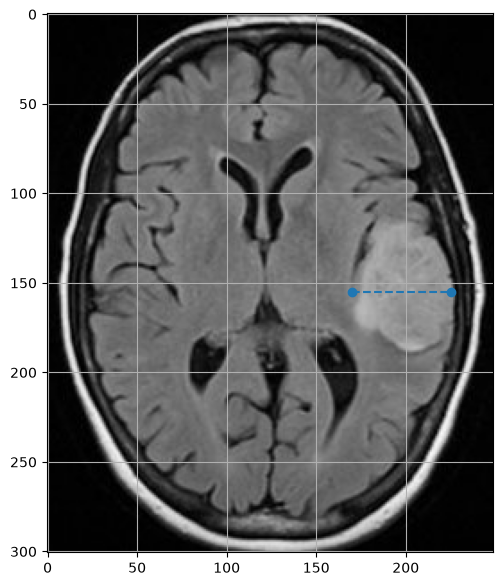

In [5]:
# vous pouvez utiliser ax.imshow(img) puis ax.plot(x, y) pour afficher une image et y superposer des points
# vous pouvez afficher la grille sur l'image avec plt.grid() pour mieux trouver les positions en pixel
fig, ax = plt.subplots() #créer la figure et les axes sur lesquels on affiche l'image.

ax.imshow(img)

x = [170, 225] #Les valeurs ont été déduites à partir de la grille et les axes
y = [155, 155] #y constant pour avoir une ligne horizontale passant par le centre

ax.plot(x, y, 'o--')

ax.grid()
plt.show()


**3.** Définissez la méthode ```taillePixel(x0, y0, x1, y1, ref)``` qui calcule la taille physique d'un pixel en millimètre.

In [6]:
def taille_pixel(x0, y0, x1, y1, ref):
    """Calcule la taille d'un pixel en fonction des coordonnées d'un objet et sa taille de référence
    @param x0  La coordonnée x du point 0
    @param y0  La coordonnée y du point 0
    @param x1  La coordonnée x du point 1
    @param y1  La coordonnée y du point 1
    @param ref La taille physique en mm de l'objet défini par les points 0 et 1
    @return    La taille physique d'un pixel en millimètre
    """
    
    distance_pixel = np.sqrt((x1 - x0)**2 + (y1 - y0)**2)
    taille = ref / distance_pixel
    return taille

**4.** La largeur de la tumeur est de 3 cm. Déduisez la largeur d'un pixel en millimètre.

In [7]:
largeur_pixel = taille_pixel(170, 155, 225, 155, 30)

print("Largeur d'un pixel :", largeur_pixel, "mm")

Largeur d'un pixel : 0.5454545454545454 mm


**5.** Définissez la méthode ```downsample(img, f)```.

In [8]:
def downsample(img, f):
    """Sous-échantillone l'image img d'un facteur f
    @param img  L'image à sous-échantilloner.
    @param f    Le facteur de sous-échantillonage (un pixel sur f est conservé).
    @return     L'image sous-échantillonée: sa taille est celle d'img divisée par f.
    """
    return img[::f, ::f]

**6.** Affichez l'image de la tumeur sous-échantillonnée avec ```f=2, 3, 4```. Affichez le facteur de downsampling ainsi que la taille de l'image downsamplée dans le titre de la figure. Comment évolue la largeur d'un pixel lors du sous-échantillonage? Donnez un avantage et un inconvénient de l'utilisation d'une image médicale downsamplée plutôt que l'image pleine résolution. 

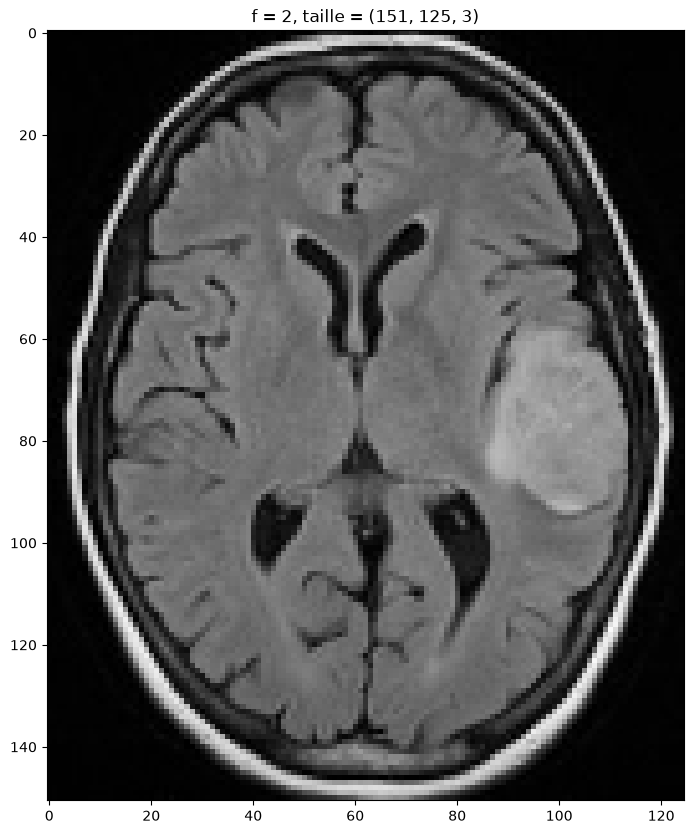

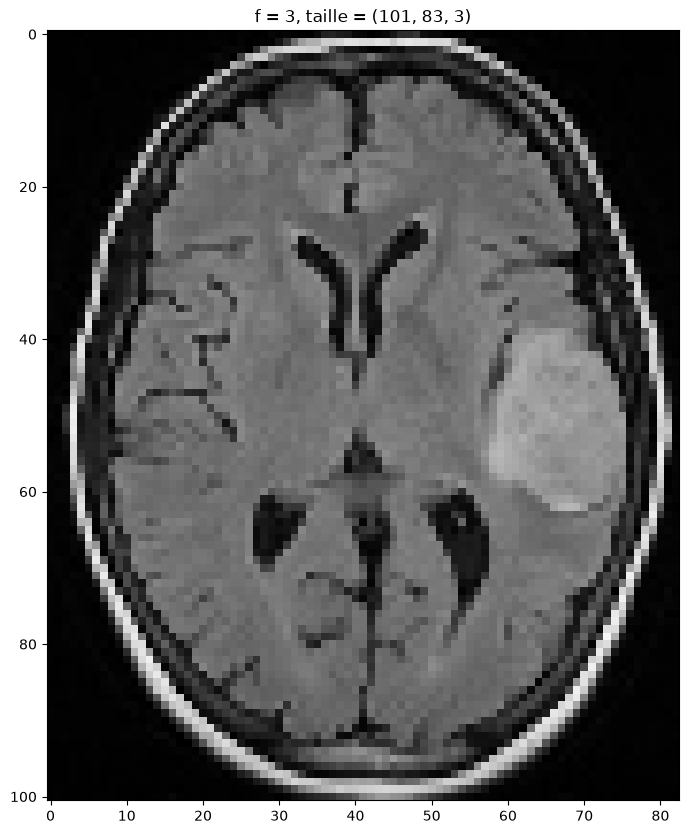

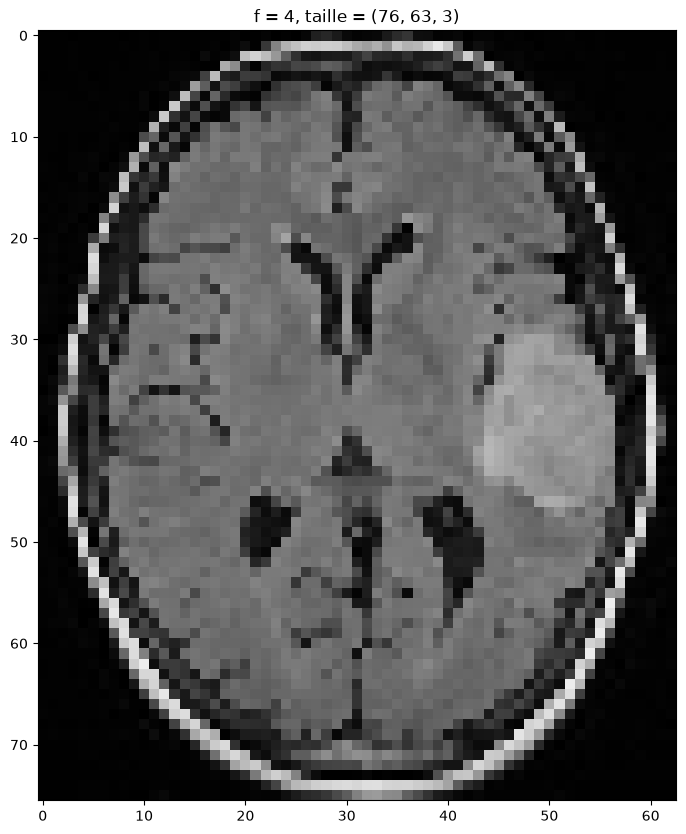

In [22]:
# pour inclure la valeur d'une variable dans un string, vous pouvez utiliser la syntaxe suivante (pour une variable x):
# f"ma variable : {x}"              ou encore
# "ma variable :{:.2f}".format(x)   pour forcer l'affichage à afficher une valeur flottante avec 2 décimales
for f in [2, 3, 4]:
    img_reduite = downsample(img, f) # Sous-échantillonne l'image avec le facteur f

    plt.figure()
    plt.imshow(img_reduite)
    plt.title(f"f = {f}, taille = {img_reduite.shape}")
    plt.show()

#Lors du sous-échantillonnage, le nombre de pixels diminue alors que la région physique représentée reste la même. 
#Chaque pixel représente donc une plus grande distance physique. Ainsi, la largeur d’un pixel augmente proportionnellement 
#au facteur de sous-échantillonnage.

#Avantage: moins de pixels = plus de mémoire de stockage et de rapidité dans l'analyse.
#Inconvénient: La résolution spatiale de l'image diminue, ce qui fait qu'on perd des détails en augmentant f.

## Calibration d'un IRM

**7.** Ouvrez et affichez l'image ```resolution.png```. Affichez l'image en niveau de gris, cachez les axes et ajoutez un titre. Par dessus l'image, dessinez des lignes pointillées le long des mires verticales et horizontales. Affichez une légende pour les lignes. 

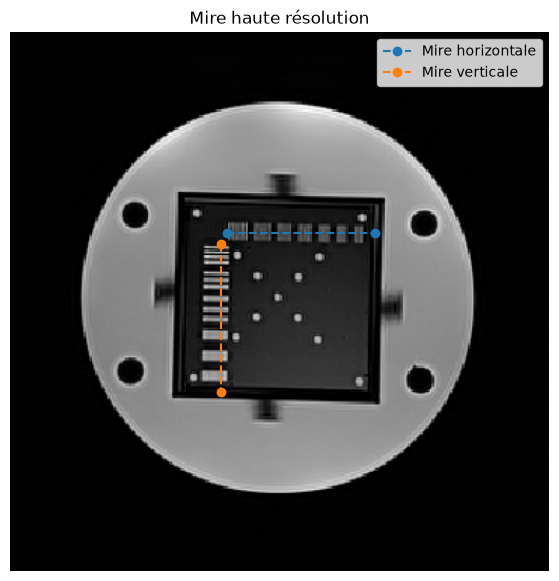

In [10]:
# np.arange, plt.imshow, plt.plot, plt.legend ...
# Pour les deux profils vous pouvez prendre: y=201:341, x=200 et y=190, x=206:346.
res = plt.imread('resolution.png')

plt.imshow(res)
plt.imshow(res, cmap="gray")
plt.axis("off")
plt.title("Mire haute résolution")

x_h = [206,346]
y_h = [190,190]

x_v = [200,200]
y_v = [201,341]

plt.plot(x_h, y_h, 'o--', label = "Mire horizontale")
plt.plot(x_v, y_v, 'o--', label = "Mire verticale")

plt.legend()

plt.show()


**8.** La largeur du cube central est de 10 cm. Déduisez la largeur d'un pixel en millimètre.

In [11]:
largeur_pixel1 = taille_pixel(160, 151, 356, 157, 100)

print("Largeur d'un pixel :", largeur_pixel1, "mm")

Largeur d'un pixel : 0.5099651909640567 mm


**9.** Quelle est la relation entre la largeur d'un pixel et la taille du plus petit objet observable ? Selon cette relation, quelle serait la taille du plus petit objet observable dans cette image ?



La taille du plus petit objet observable correspond approximativement à deux fois la largeur d’un pixel. Ainsi, si la largeur d’un pixel est d’environ 0,51 mm, le plus petit objet observable est d’environ 1,02 mm.

**10.** Afin de vérifier cette relation, affichez les profils d'intensités le long d'axes perpendiculaires aux mires. Utilisez la distance en millimètres comme abscisses. 

Quelle est l'épaisseur des plus petites mires observables? Fiez-vous au tableau 1 et à la figure 3 de l'énoncé. 

Est-ce cohérent avec votre réponse donnée à la question **9** ?

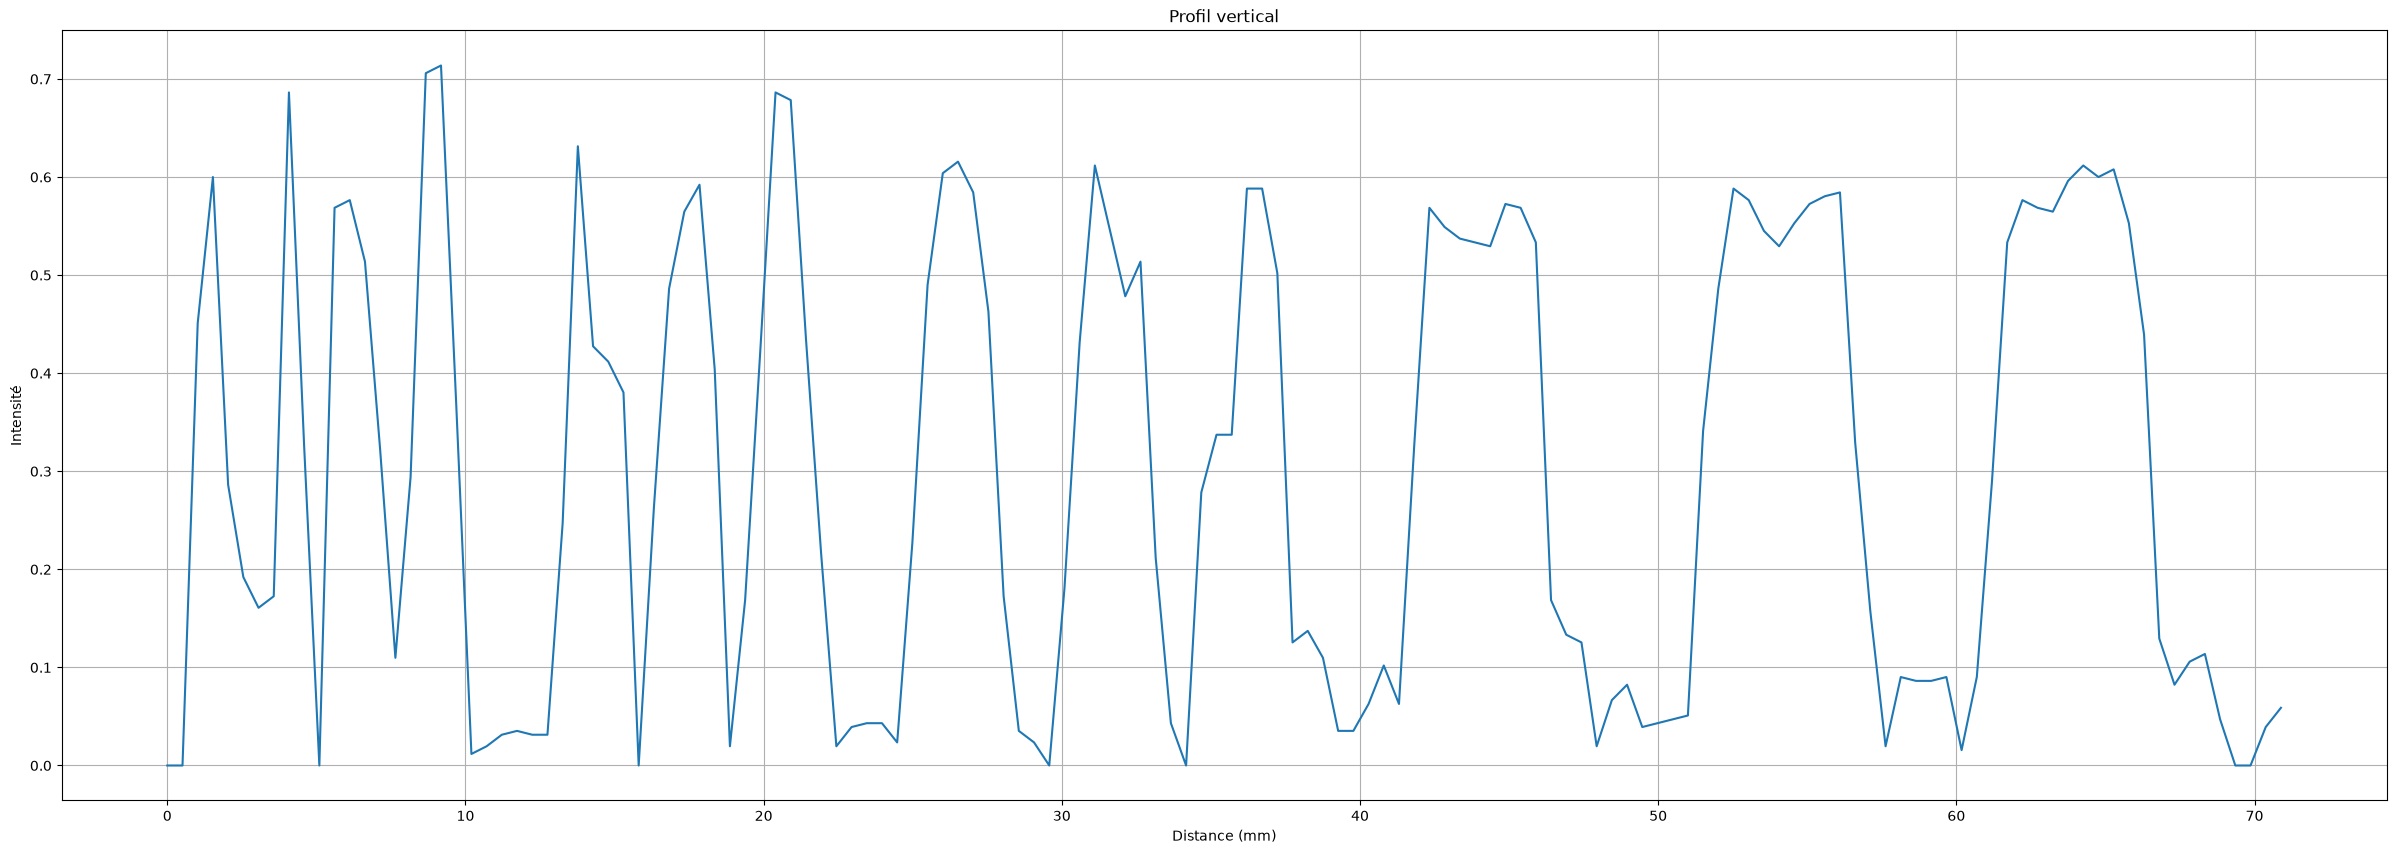

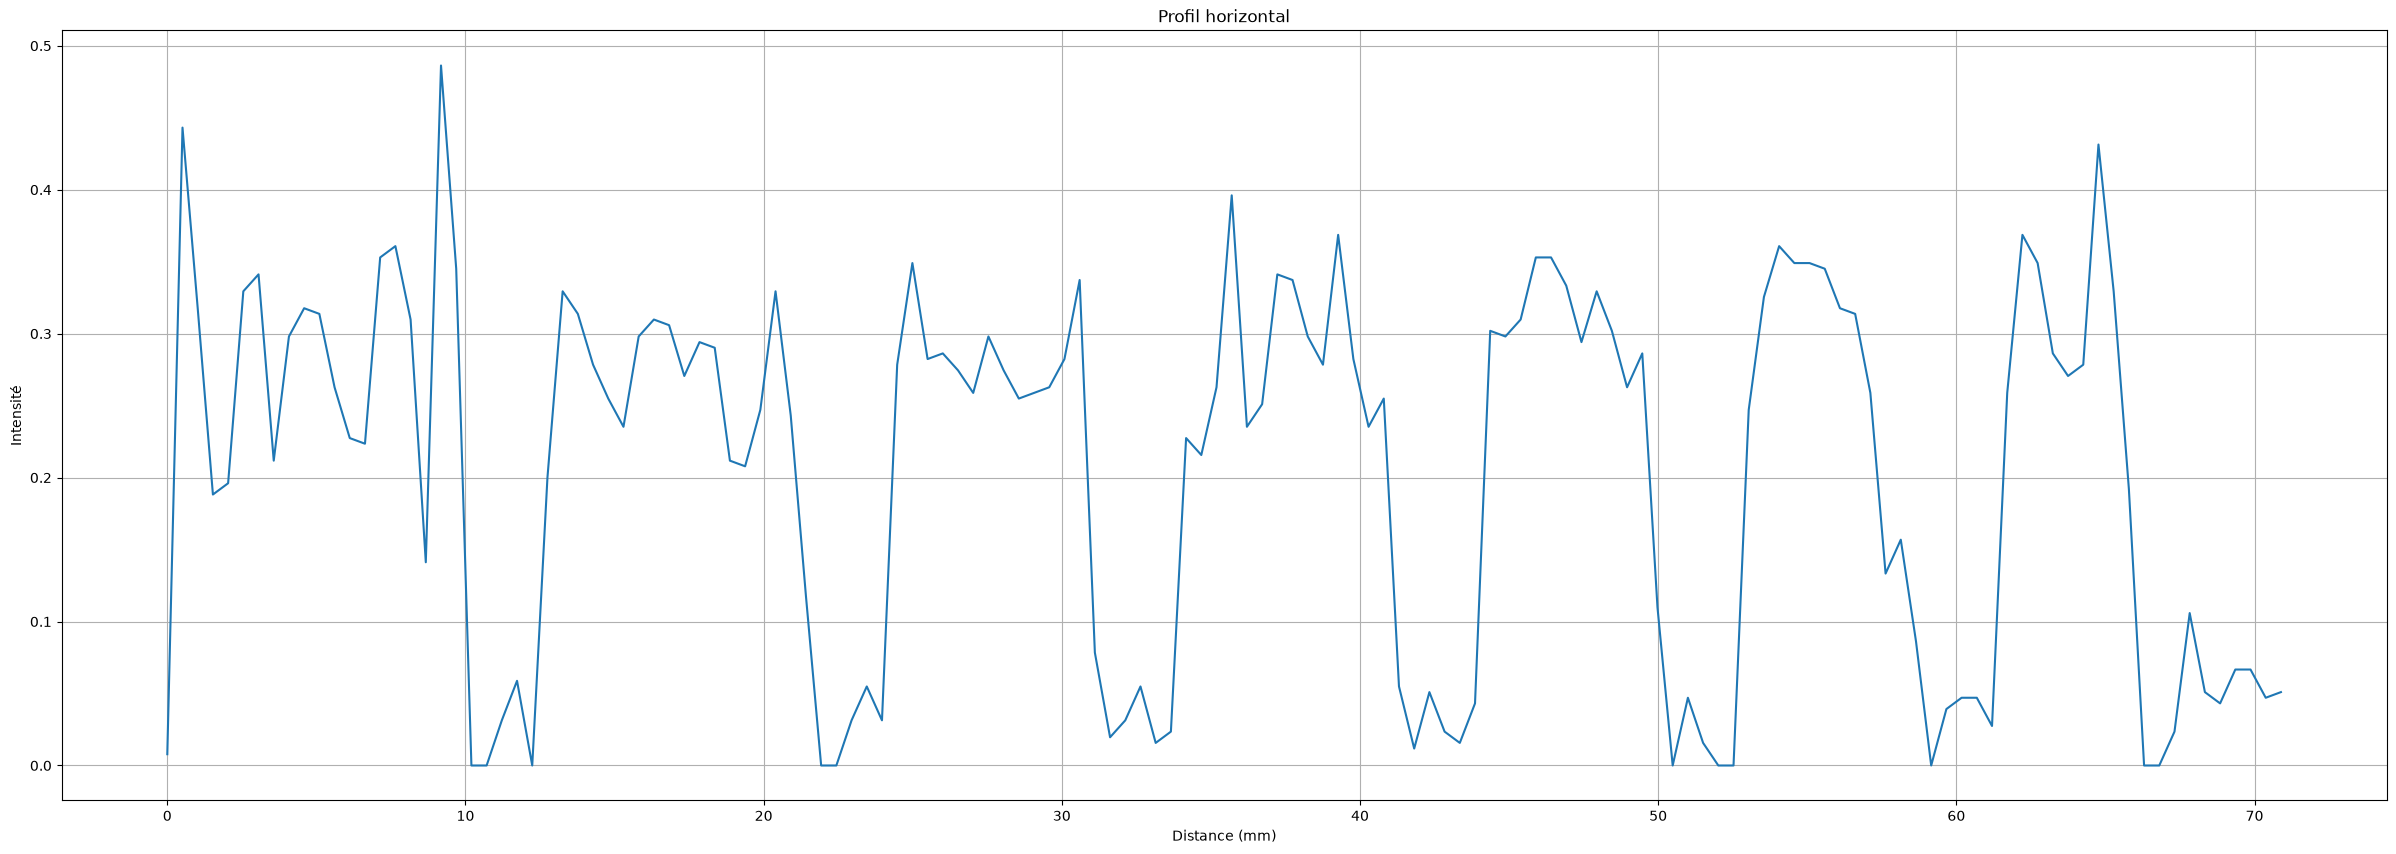

In [23]:
# Extraire les profils d'intensité
profil_vertical = res[201:341, 200]
profil_horizontal = res[190, 206:346]

# Taille d'un pixel trouvée à la Q8
taille_pix = 0.5099651909640567

# Convertir les positions des pixels en distances en mm
distance_verticale = np.arange(len(profil_vertical)) * taille_pix
distance_horizontale = np.arange(len(profil_horizontal)) * taille_pix

# Afficher le profil vertical
plt.figure()
plt.plot(distance_verticale, profil_vertical)
plt.xlabel("Distance (mm)")
plt.ylabel("Intensité")
plt.title("Profil vertical")
plt.grid()
plt.show()

# Afficher le profil horizontal
plt.figure()
plt.plot(distance_horizontale, profil_horizontal)
plt.xlabel("Distance (mm)")
plt.ylabel("Intensité")
plt.title("Profil horizontal")
plt.grid()
plt.show()

#Pour le profil vertical, toutes les mires ont une épaisseur supérieure à 1 mm et elles sont toutes distinguables sur le graphique. 
#Pour le profil horizontal, seul le bloc contenant les mires de 1 mm est clairement distinguable. Lorsque la taille des mires diminue, 
#les pics deviennent de moins en moins distincts. La plus petite mire observable est donc d’environ 1 mm, ce qui est cohérent avec le 
#résultat obtenu à la question 9.

## Mesure de l'épaisseur de coupe

**11.** Affichez les profils d'intensités des 4 rampes et mesurer graphiquement la largeur des gaussiennes à mi-hauteur. 

(Affichez les grilles sur les graphiques et augmenter la fréquence des ticks et la taille de l'image devraient faciliter la mesure).

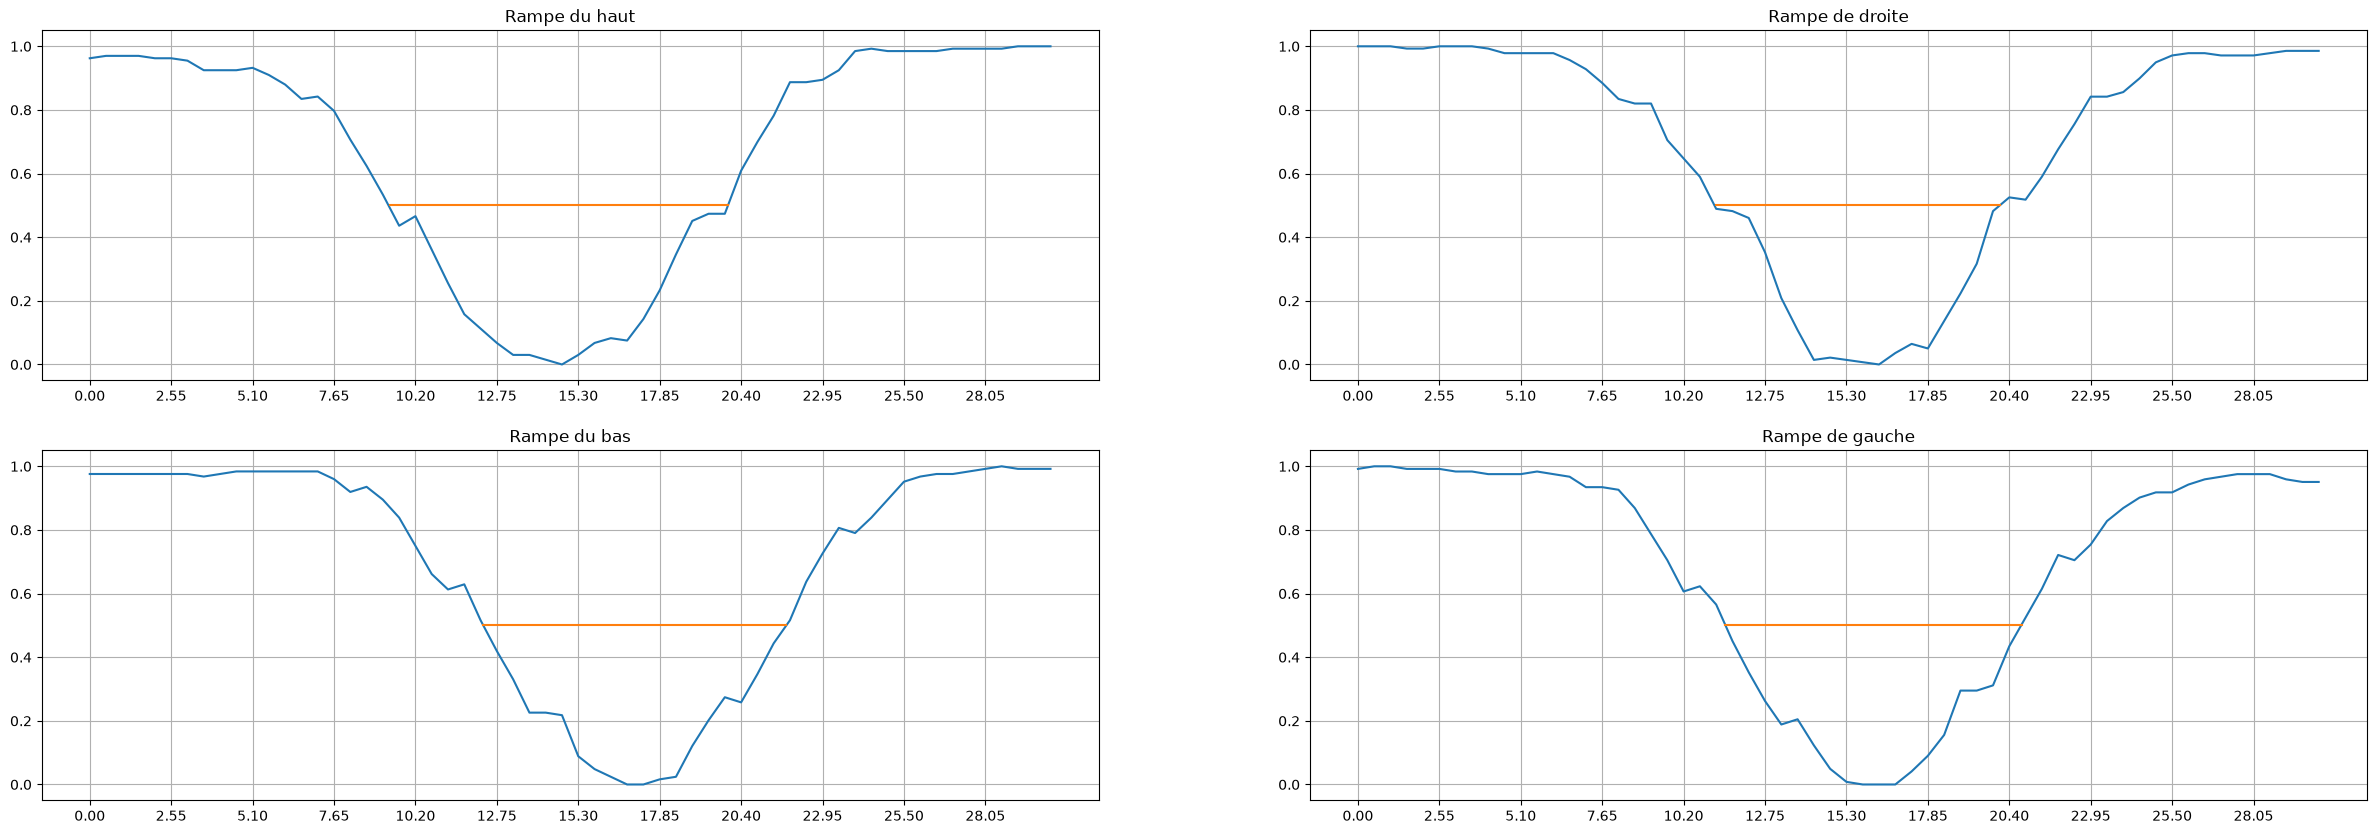

In [56]:
# Pour les profils des rampes vous pouvez prendre: y=140, x=230:290
#                                                  y=230:290, x=365
#                                                  y=360, x=210:270
#                                                  y=215:275, x=147
profil_haut = res[140, 230:290] #forme img[dim1, dim2] pour accéder aux intesités des pixels à ces positions
profil_droit = res[230:290, 365]
profil_bas = res[360, 210:270]
profil_gauche = res[215:275, 147]

#Normalisation type min-max: la valeur la plus basse donnera 0 et la valeur la plus haute donnera 1 selon la formule I = (I-Imin)/(Imax-Imin):

profil_haut_norm = (profil_haut - np.min(profil_haut))/(np.max(profil_haut)-np.min(profil_haut))
profil_droit_norm = (profil_droit - np.min(profil_droit))/(np.max(profil_droit)-np.min(profil_droit))
profil_bas_norm = (profil_bas - np.min(profil_bas))/(np.max(profil_bas)-np.min(profil_bas))
profil_gauche_norm = (profil_gauche - np.min(profil_gauche))/(np.max(profil_gauche)-np.min(profil_gauche))


fig, ax = plt.subplots(2, 2)
x_mm = np.arange(60) * largeur_pixel1
ticks_px = np.arange(0, 60, 5)
ticks_mm = ticks_px * largeur_pixel1

ax[0,0].plot(x_mm, profil_haut_norm)
ax[0,0].set_title("Rampe du haut")
ax[0,0].grid()
ax[0,0].set_xticks(ticks_mm)
ax[0,0].plot([9.4, 20], [0.5, 0.5]) #valeurs déterminées graphiquement => FWHM = 20 - 9.4 = 10.6 mm

ax[0,1].plot(x_mm, profil_droit_norm)
ax[0,1].set_title("Rampe de droite")
ax[0,1].grid()
ax[0,1].set_xticks(ticks_mm)
ax[0,1].plot([11.2, 20.1], [0.5, 0.5]) #valeurs déterminées graphiquement => FWHM = 20.1 - 11.2 = 8.9 mm

ax[1,0].plot(x_mm, profil_bas_norm)
ax[1,0].set_title("Rampe du bas")
ax[1,0].grid()
ax[1,0].set_xticks(ticks_mm)
ax[1,0].plot([12.3, 21.8], [0.5, 0.5]) #valeurs déterminées graphiquement => FWHM = 21.8 - 12.3 = 9.5 mm

ax[1,1].plot(x_mm, profil_gauche_norm)
ax[1,1].set_title("Rampe de gauche")
ax[1,1].grid()
ax[1,1].set_xticks(ticks_mm)
ax[1,1].plot([11.5, 20.8], [0.5, 0.5]) #valeurs déterminées graphiquement => FWHM = 20.8 - 11.5 = 9.3 mm

plt.show()

**12.** L'épaisseur de la coupe est donnée par $e=\tan(14^\circ) \times FWHM$ où $FWHM$ est la largeur à mi-hauteur en mm. Sachant que les paramètres de l'IRM indiquent une épaisseur de coupe théorique de $2\pm0.3$ mm, passerait-il le controle qualité?

In [58]:
#Valuers de FWMHH détéerminées graphiquement de Q11
FWHM_haut = 10.6 
FWHM_droite = 8.9 
FWHM_bas = 9.5 
FWHM_gauche = 9.2

e_haut = np.tan(np.deg2rad(14)) * FWHM_haut
e_droite = np.tan(np.deg2rad(14)) * FWHM_droite
e_bas = np.tan(np.deg2rad(14)) * FWHM_bas
e_gauche = np.tan(np.deg2rad(14)) * FWHM_gauche

print(f"e_haut = {e_haut:.2f} mm, e_droite = {e_droite:.2f} mm, e_bas = {e_bas:.2f} mm, e_gauche = {e_gauche:.2f}")

e_haut = 2.64 mm, e_droite = 2.22 mm, e_bas = 2.37 mm, e_gauche = 2.29


# Exercice II: Analyse du contraste et du bruit
## Mesure du contraste

In [14]:
# pour étendre l'affichage des figures encore plus, facultatif !
plt.rcParams["figure.figsize"] = (20, 7)

**1.** Chargez  et affichez l'image ```oct.png```.

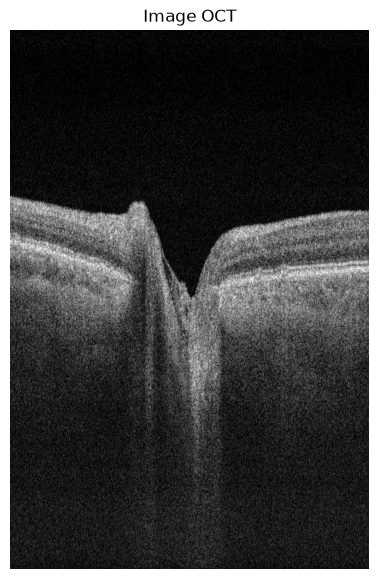

In [15]:
img_oct = plt.imread('oct.png')

plt.imshow(img_oct, cmap='gray')
plt.title("Image OCT")
plt.axis('off')
plt.show()

**2.** Chargez  et affichez les segmentations ```mask_choroid_left.npy```, ```mask_choroid_right.npy```, ```mask_rpe_left.npy```, ```mask_rpe_right.npy``` et ```mask_onh.npy```.

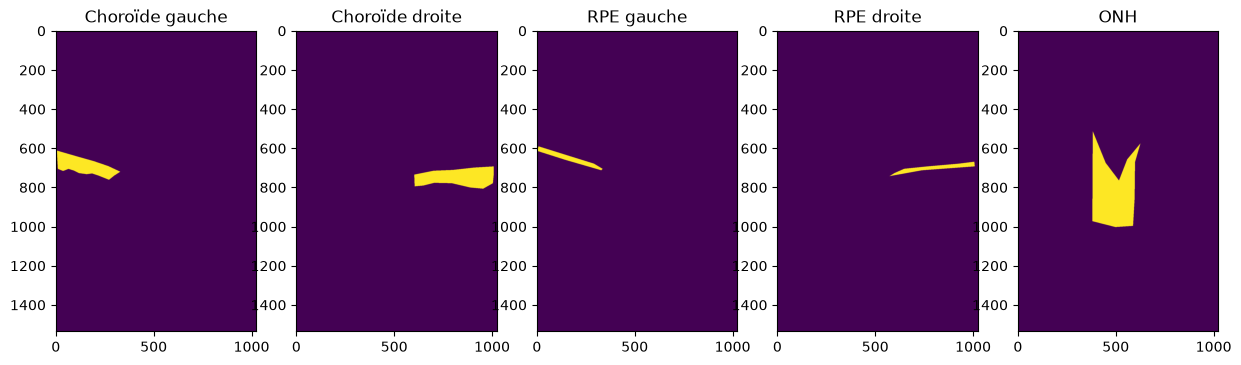

In [16]:
mask_choroid_left = np.load('mask_choroid_left.npy')
mask_choroid_right = np.load('mask_choroid_right.npy')
mask_rpe_left = np.load('mask_rpe_left.npy')
mask_rpe_right = np.load('mask_rpe_right.npy')
mask_onh = np.load('mask_onh.npy')

# Afficher les 5 masques
fig, ax = plt.subplots(1, 5, figsize=(15, 4))

ax[0].imshow(mask_choroid_left)
ax[0].set_title("Choroïde gauche")

ax[1].imshow(mask_choroid_right)
ax[1].set_title("Choroïde droite")

ax[2].imshow(mask_rpe_left)
ax[2].set_title("RPE gauche")

ax[3].imshow(mask_rpe_right)
ax[3].set_title("RPE droite")

ax[4].imshow(mask_onh)
ax[4].set_title("ONH")

plt.show()

**3.** Regrouper les segmentations de la choroide et de la RPE en un seul masque par région (1 masque pour la choroide, gauche et droite, etc.). Affichez les segmentations regroupées.

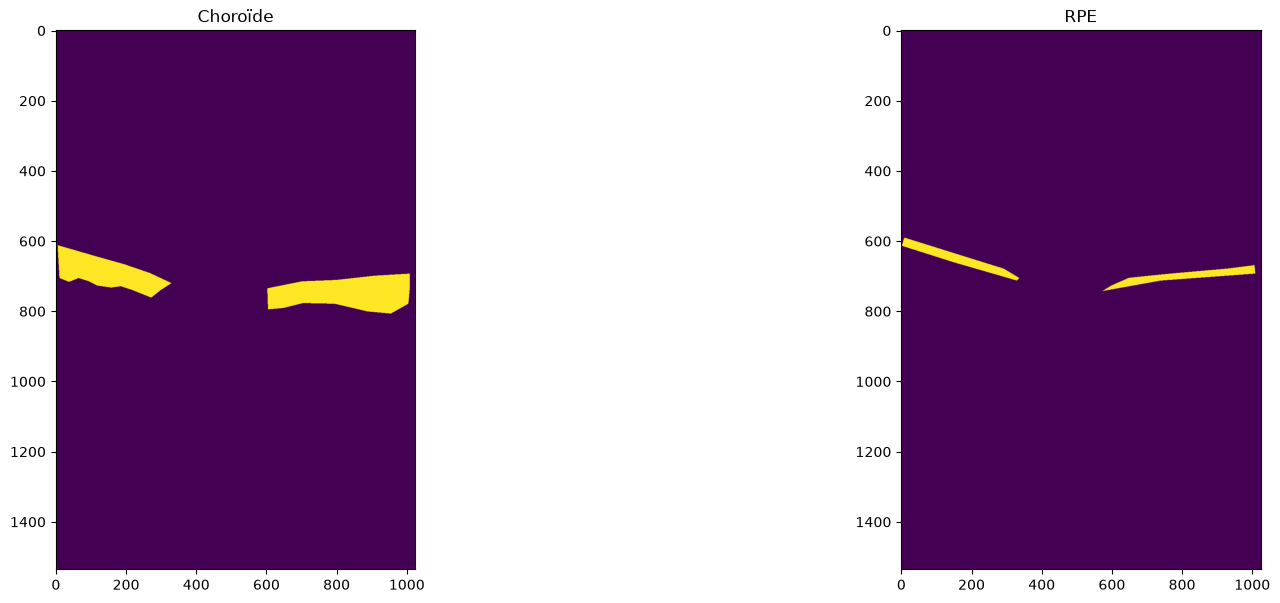

In [17]:
# Regroupement des masques gauche et droit
mask_choroid = np.logical_or(mask_choroid_left, mask_choroid_right)
mask_rpe = np.logical_or(mask_rpe_left, mask_rpe_right)

fig, ax = plt.subplots(1, 2)

ax[0].imshow(mask_choroid)
ax[0].set_title("Choroïde")

ax[1].imshow(mask_rpe)
ax[1].set_title("RPE")

plt.show()

**4.** Utilisez le masque  ```mask_retina.npy ``` pour définir un masque du fond de l'image (et pas de la rétine).

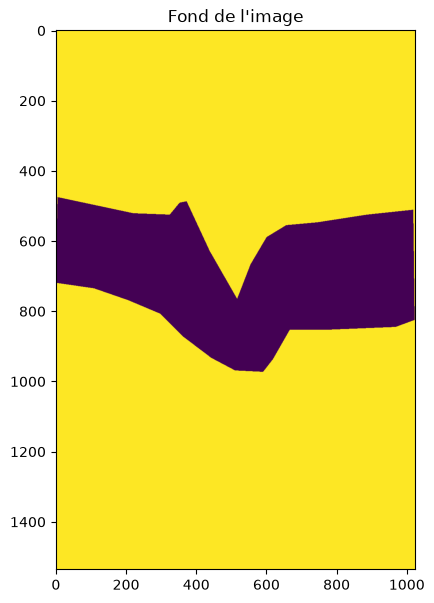

In [18]:
mask_retina = np.load('mask_retina.npy')

# Créer un masque rempli de 1
mask_background = np.ones(mask_retina.shape)

# Mettre à 0 les pixels qui appartiennent à la rétine
mask_background[mask_retina == 1] = 0

plt.imshow(mask_background)
plt.title("Fond de l'image")
plt.show()

**5.** Calculez l'intensité moyenne sur ces 3 régions (choroide, RPE et tête du nerf optique) et sur le fond de l'image. En déduire le contraste entre chaque région et le fond de l'image OCT. Quelle est la zone de la rétine où le contraste est le meilleur ?

In [19]:
# Calcul de l'intensité moyenne de chaque région
I_choroid = np.mean(img_oct[mask_choroid])
I_rpe = np.mean(img_oct[mask_rpe])
I_onh = np.mean(img_oct[mask_onh])
I_background = np.mean(img_oct[mask_background == 1])

# Calcul du contraste de chaque région par rapport au fond
C_choroid = (I_choroid - I_background) / I_background
C_rpe = (I_rpe - I_background) / I_background
C_onh = (I_onh - I_background) / I_background

print("Contraste choroïde :", C_choroid)
print("Contraste RPE :", C_rpe)
print("Contraste tête du nerf optique :", C_onh)

Contraste choroïde : 4.17295
Contraste RPE : 6.525108
Contraste tête du nerf optique : -0.72556776


## Mesure du Rapport Contraste/Bruit

**6.** Ouvrez et affichez les images ```oct.png```, ```oct_2.png```,  ```oct_3.png```, ```oct_4.png```, ```oct_5.png```. 

In [20]:
plt.rcParams["figure.figsize"] = (30, 10)

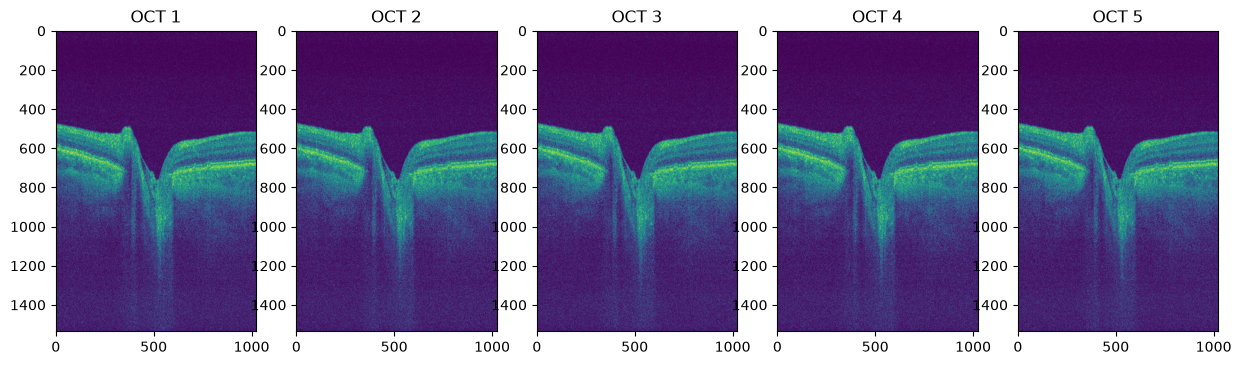

In [60]:
img_oct = plt.imread('oct.png')
img_oct2 = plt.imread('oct_2.png')
img_oct3 = plt.imread('oct_3.png')
img_oct4 = plt.imread('oct_4.png')
img_oct5 = plt.imread('oct_5.png')

fig, ax = plt.subplots(1, 5, figsize=(15, 4))

ax[0].imshow(img_oct)
ax[0].set_title("OCT 1")

ax[1].imshow(img_oct2)
ax[1].set_title("OCT 2")

ax[2].imshow(img_oct3)
ax[2].set_title("OCT 3")

ax[3].imshow(img_oct4)
ax[3].set_title("OCT 4")

ax[4].imshow(img_oct5)
ax[4].set_title("OCT 5")

plt.show()

**7.** En utilisant la segmentation de la rétine et la segmentation de la région avec le plus grand contraste (question précédente), calculez le CNR en décibel sur ces 5 images. 

In [81]:
images_oct = [img_oct, img_oct2, img_oct3, img_oct4, img_oct5]

liste_CNR_dB = []

for img in images_oct:
    
    mu_rpe = np.mean(img[mask_rpe])
    mu_background = np.mean(img[mask_background == 1])
    std_background = np.std(img[mask_background == 1])
    
    CNR = (mu_rpe - mu_background) / std_background
    CNR_dB = round(float(20 * np.log10(CNR)), 2)
    
    liste_CNR_dB.append(CNR_dB)

resultats = np.array( [[1, 2, 3, 4, 5], liste_CNR_dB])
print(resultats)

[[ 1.    2.    3.    4.    5.  ]
 [15.21 15.18 15.14 15.08 15.12]]


**8.** Calculer une image moyenne de ces 5 images, qui sera une estimation de l'image OCT débruitée. Affichez côte à côte une des images originale et l'image moyennée. Quelles différences remarquez-vous ?

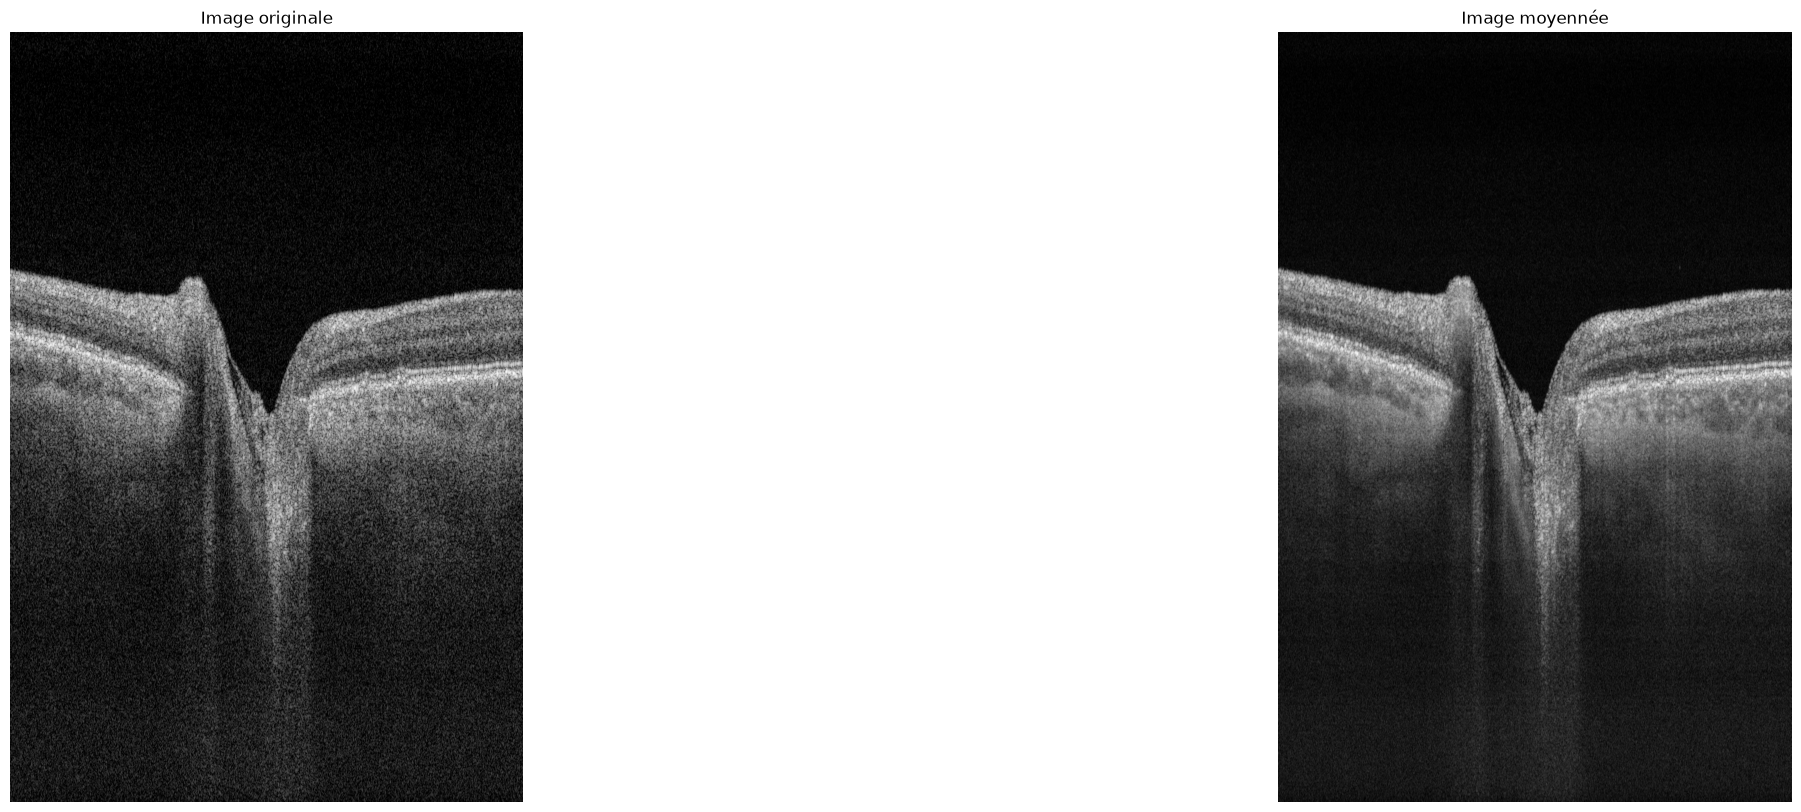

In [89]:
img_moy = np.mean(images_oct, axis=0) #permet de comparer pixel par pixel (images ne bougent pas entre acquisitions)
                                          #axis = 0 permet de prendre la première dimension donc le nombre des images en 
                                          #maintenant les deux autres dimensions: hauteur et largeur

fig, ax = plt.subplots(1, 2)

ax[0].imshow(img_oct, cmap="gray")
ax[0].set_title("Image originale")
ax[0].axis("off")

ax[1].imshow(img_moy, cmap="gray")
ax[1].set_title("Image moyennée")
ax[1].axis("off")

plt.show()

**9.** Calculer le CNR sur une des images originales, l'image moyennée calculée à la question précédente, et sur l'image ```ave.png``` fournie. Affichez les trois images côte-à-côte et comparez leurs CNRs. Quelle image obtient le CNR le plus élevé ? 

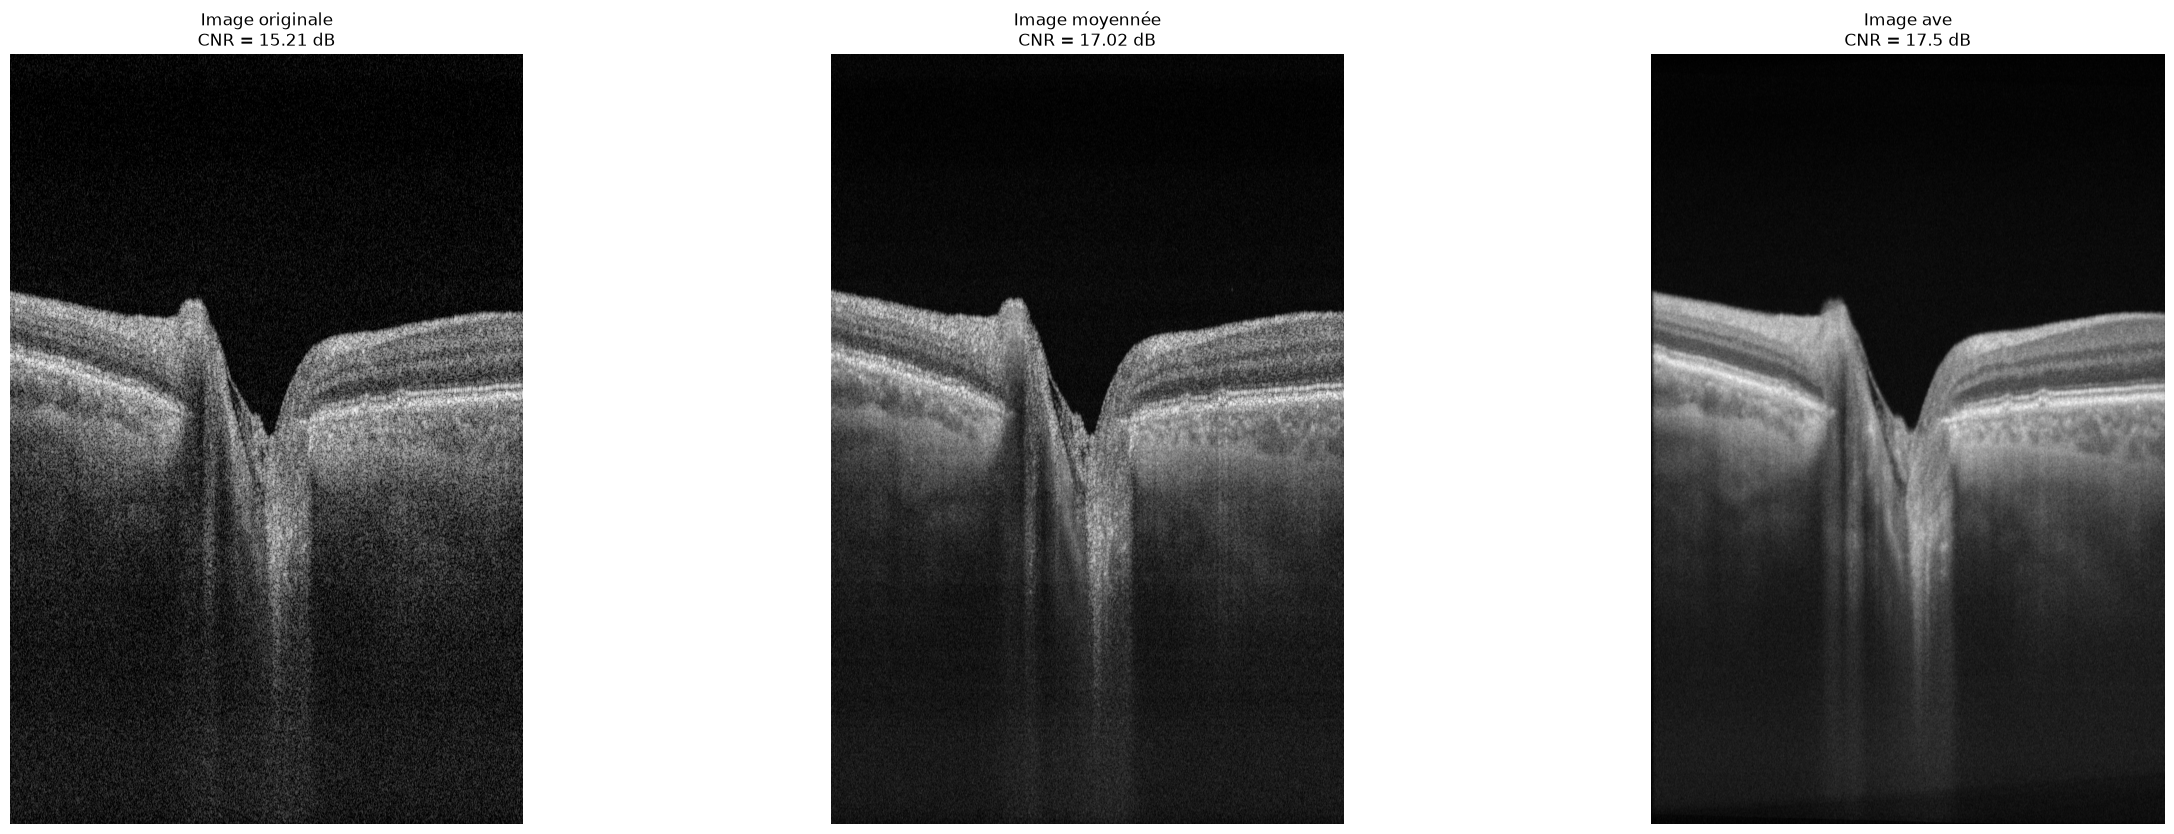

In [95]:
img_ave = plt.imread('ave.png')

images_moyennage = [img_oct, img_moy, img_ave]

liste_CNR_dB_moyennage = []

for img in images_moyennage:
    
    mu_rpe = np.mean(img[mask_rpe])
    mu_background = np.mean(img[mask_background == 1])
    std_background = np.std(img[mask_background == 1])
    
    CNR = (mu_rpe - mu_background) / std_background
    CNR_dB = round(float(20 * np.log10(CNR)), 2)
    
    liste_CNR_dB_moyennage.append(CNR_dB)

fig, ax = plt.subplots(1, 3)

ax[0].imshow(img_oct, cmap="gray")
ax[0].set_title(f"Image originale\nCNR = {liste_CNR_dB_moyennage[0]} dB")
ax[0].axis("off")

ax[1].imshow(img_moy, cmap="gray")
ax[1].set_title(f"Image moyennée\nCNR = {liste_CNR_dB_moyennage[1]} dB")
ax[1].axis("off")

ax[2].imshow(img_ave, cmap="gray")
ax[2].set_title(f"Image ave\nCNR = {liste_CNR_dB_moyennage[2]} dB")
ax[2].axis("off")

plt.show()

**10.** Que pouvez-vous conclure sur la technique de moyennage comme technique de débruitage ? (Pourriez-vous utiliser la technique de moyennage en tout temps ? Quelles conditions doivent être respectées pour que la technique fonctionne bien ?)

En comparant l'image originale à l'image moyennée, on remarque que le moyennage est une bonne méthode de réduction du bruit et lissage. Par contre, sur l'image ave on remarque un aspect de flou qui commence à se créer et une perte de la clarté des structures principales. Ceci suppose donc qu'on a effectué le moyennage mais sur une durée d'acquisition plus longue (plus d'images que les 5 utilisées ont été considérés). Ceci confirme le principe par lequel la technique du moyennage ne fonctionne que si le bruit est aléatoire et donc, que la structure ne bouge pas entre les différentes images acquises. Il faut donc que le temps d'acquisition soit minime pour que la technique fonctionne bien.  

**8.** Que représente le rapport contraste/bruit? Est-il préférable d'avoir un CNR faible ou fort? 



Le CNR représente une mesure du contraste entre le tissu d'intérêt et le fond de l'image qui comporte le bruit indésirable. Selon la formule mathématique, un CNR plus fort est préférable car il indique que la différenciation entre le signal de la structure cible et celui du fond est plus importante. 

**9.** Nommez un avantage de calculer le rapport contraste/bruit par rapport au rapport signal/bruit. 

Le SNR évalue le signal moyen d'une région complète par rapport au bruit de fond. Cependant, il existe parfois des signaux moins importants à l'évaluation qui se retrouvent dans la zone et influencent son signal. Le CNR est donc plus spécifique puisqu'il prend en compte le signal du tissu d'intérêt plutôt. 